In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

In [3]:
url = "https://webscraper.io/test-sites/e-commerce/static"
HEADERS = {"User = Agent":"Mozilla/5.0"}#Headers tells the website that we are a normal user and no a robot . some website blocks robots

response = requests.get(url,headers=HEADERS) #  (request.get) fetches the data from the website
soup = BeautifulSoup(response.text , "html.parser") # convert the website content into a readable format
products = soup.find_all("div" , class_="thumbnail")

In [4]:
data = [] #create an empty list to store data

for product in products: #
    name = product.find("a" , class_="title")
    product_name = name.text.strip() if name else None #this is a short form for if nd else condititon
    
    brand = product_name.split()[0] if product_name else None
    
    price = product.find("h4",class_="price")
    discounted_price = float(price.text.replace("$","")) if price else None
    
    rating = len(product.find_all("span",class_="glyphicon-star"))
    
    review = product.find("p",class_="pull-right")
    num_reviews = int(reviews.text.split()[0]) if review else 0

    data.append({
        "Product Name": product_name,
        "Brand" : brand,
        "Original Price" : None,
        "Discount Price" : discounted_price,
        "Discounted Percentage" : None,
        "Rating" : rating,
        "Number of Review" : num_reviews 
    })

In [5]:
brand

'Hewlett'

In [6]:
df = pd.DataFrame(data)
df.to_csv("products.csv")

print("scraping completed. data saved to prducts.csv")

scraping completed. data saved to prducts.csv


In [9]:
import pandas as pd 

df = pd.read_csv("products.csv")

print("\nTop Brands:")
print(df["Brand"].value_counts())


Top Brands:
Brand
Toshiba    1
HP         1
Hewlett    1
Name: count, dtype: int64


In [12]:
print("n\Price Statistics:")
print(df["Discounted Price"].describe())

n\Price Statistics:
count       3.000000
mean     1001.713333
std       371.753297
min       577.990000
25%       866.015000
50%      1154.040000
75%      1213.575000
max      1273.110000
Name: Discounted Price, dtype: float64


In [13]:
print("\nAverage Rating:",df["Rating"].mean())


Average Rating: 0.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

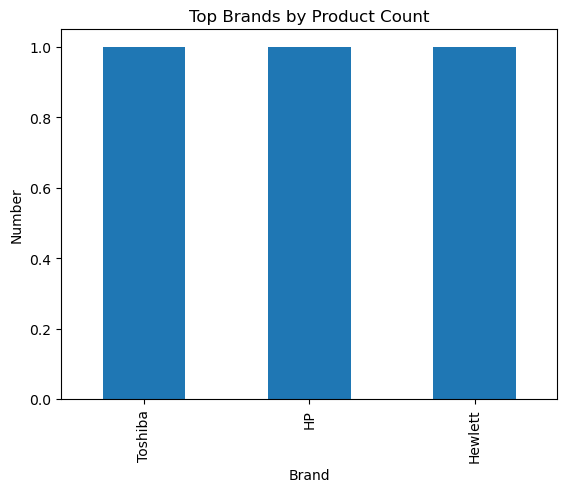

In [25]:
df = pd.read_csv("products.csv")

#Top Brands
df["Brand"].value_counts().plot(kind="bar")
plt.title("Top Brands by Product Count")
plt.xlabel("Brand")
plt.ylabel("Number")
plt.show

In [19]:
df.head()

,Unnamed: 0,Product Name,Brand,Original Price,Discounted Price,Discounted Percentage,Rating,Number of Review
0,0,Toshiba Porteg...,Toshiba,NaN,1154.04,NaN,0,0
1,1,HP 350 G1,HP,NaN,577.99,NaN,0,0
2,2,Hewlett Packar...,Hewlett,NaN,1273.11,NaN,0,0


In [29]:
df.tail(2)

,Unnamed: 0,Product Name,Brand,Original Price,Discounted Price,Discounted Percentage,Rating,Number of Review
1,1,HP 350 G1,HP,NaN,577.99,NaN,0,0
2,2,Hewlett Packar...,Hewlett,NaN,1273.11,NaN,0,0


<function matplotlib.pyplot.show(close=None, block=None)>

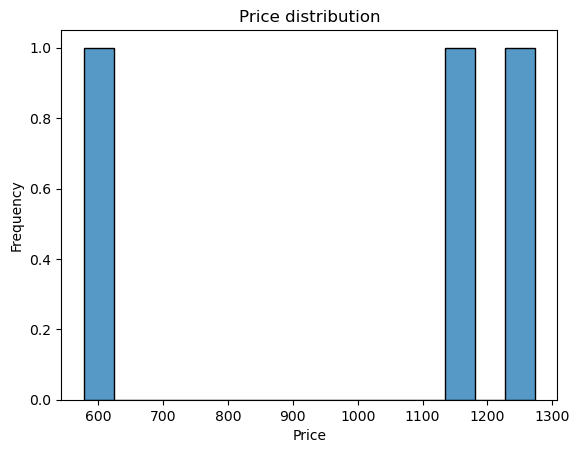

In [31]:
#price dictribution
sns.histplot(df["Discounted Price"], bins = 15)
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

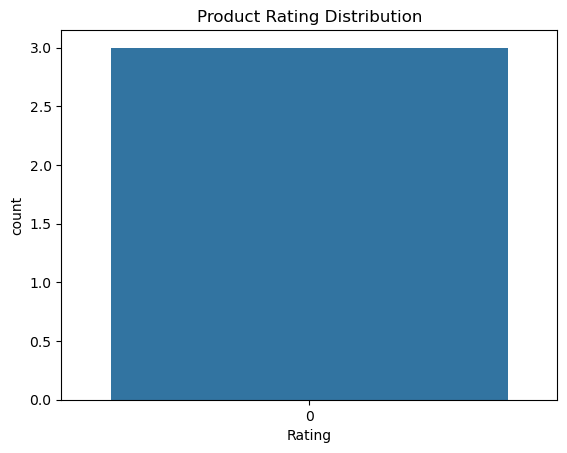

In [32]:
#Ratings
sns.countplot(x="Rating", data=df)
plt.title("Product Rating Distribution")
plt.show